#Analyzing drop in revenue

to find out reason behind the drop in revenue.

In [ ]:
# importing libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### reading and loading data and performing EDA

In [ ]:
# reading customers data
customers = pd.read_csv("customers.csv")
customers.head()

,customer_id,customer_name,signup_date
0,101,Ravi,2023-11-10
1,102,Sneha,2023-12-01
2,103,Amit,2023-12-15
3,104,Pooja,2024-01-05
4,105,Kiran,2024-01-20


In [ ]:
# reading orders data
orders = pd.read_csv("orders.csv")
orders.head()

,order_id,customer_id,product_id,order_date,city,quantity
0,1,101,201,2024-01-05,Hyderabad,1
1,2,102,202,2024-01-06,Bangalore,2
2,3,103,203,2024-01-10,Chennai,1
3,4,101,202,2024-02-12,Hyderabad,1
4,5,104,204,2024-02-18,Bangalore,3


In [ ]:
# reading products data
products = pd.read_csv("products.csv")
products.head()

,product_id,product_name,category,price
0,201,Laptop,Electronics,70000
1,202,Mobile,Electronics,20000
2,203,Tablet,Electronics,15000
3,204,Shoes,Fashion,3000
4,205,Watch,Fashion,5000


In [ ]:
# joining tables accordingly
df = pd.merge(customers, orders, on="customer_id", how = "inner")
df = pd.merge(df, products, on="product_id", how = "inner")
df

,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity,product_name,category,price
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1,Laptop,Electronics,70000
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1,Mobile,Electronics,20000
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1,Laptop,Electronics,70000
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2,Mobile,Electronics,20000
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1,Tablet,Electronics,15000
5,103,Amit,2023-12-15,3,203,2024-01-10,Chennai,1,Tablet,Electronics,15000
6,103,Amit,2023-12-15,12,205,2024-05-09,Chennai,1,Watch,Fashion,5000
7,104,Pooja,2024-01-05,5,204,2024-02-18,Bangalore,3,Shoes,Fashion,3000
8,104,Pooja,2024-01-05,13,202,2024-05-15,Bangalore,1,Mobile,Electronics,20000
9,105,Kiran,2024-01-20,6,201,2024-03-05,Chennai,1,Laptop,Electronics,70000


### EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    20 non-null     int64 
 1   customer_name  20 non-null     object
 2   signup_date    20 non-null     object
 3   order_id       20 non-null     int64 
 4   product_id     20 non-null     int64 
 5   order_date     20 non-null     object
 6   city           20 non-null     object
 7   quantity       20 non-null     int64 
 8   product_name   20 non-null     object
 9   category       20 non-null     object
 10  price          20 non-null     int64 
dtypes: int64(5), object(6)
memory usage: 1.8+ KB


In [ ]:
#converting object date columns into datetime format
df["signup_date"] = pd.to_datetime(df["signup_date"])
df["order_date"] = pd.to_datetime(df["order_date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customer_id    20 non-null     int64         
 1   customer_name  20 non-null     object        
 2   signup_date    20 non-null     datetime64[ns]
 3   order_id       20 non-null     int64         
 4   product_id     20 non-null     int64         
 5   order_date     20 non-null     datetime64[ns]
 6   city           20 non-null     object        
 7   quantity       20 non-null     int64         
 8   product_name   20 non-null     object        
 9   category       20 non-null     object        
 10  price          20 non-null     int64         
dtypes: datetime64[ns](2), int64(5), object(4)
memory usage: 1.8+ KB


In [ ]:
# creating new column: revenue
# (revenue = price*quantity)
df["revenue"] = df["price"] * df["quantity"]
df.head()

,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity,product_name,category,price,revenue
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1,Laptop,Electronics,70000,70000
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1,Mobile,Electronics,20000,20000
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1,Laptop,Electronics,70000,70000
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2,Mobile,Electronics,20000,40000
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1,Tablet,Electronics,15000,15000


In [ ]:
# find revenue trend (line chart)
revenue = df.groupby("order_date")["revenue"].sum()
revenue = pd.DataFrame(revenue).reset_index()
revenue

,order_date,revenue
0,2024-01-05,70000
1,2024-01-06,40000
2,2024-01-10,15000
3,2024-02-12,20000
4,2024-02-18,9000
5,2024-03-05,70000
6,2024-03-15,15000
7,2024-04-02,10000
8,2024-04-10,20000
9,2024-04-18,6000


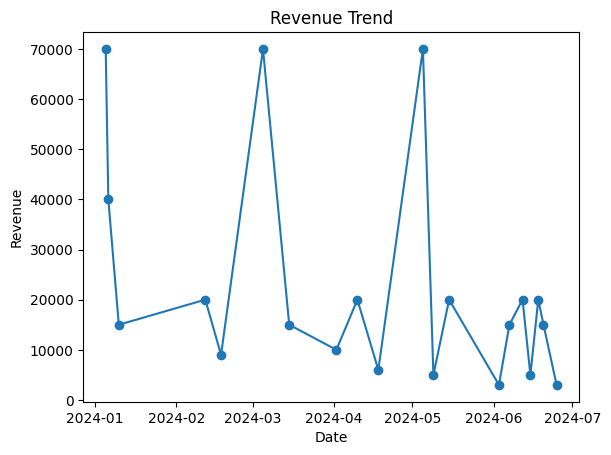

In [ ]:
plt.plot(revenue["order_date"], revenue["revenue"], marker = "o")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.title("Revenue Trend")
plt.show()

- **sales are low in june and july**
- **drop started mid may**

In [ ]:
df["city"].unique()

array(['Hyderabad', 'Bangalore', 'Chennai'], dtype=object)

In [ ]:
# find revenue trend (line chart)
revenue = df.groupby("city")["revenue"].sum()
revenue = pd.DataFrame(revenue).reset_index()
revenue

,city,revenue
0,Bangalore,136000
1,Chennai,140000
2,Hyderabad,175000


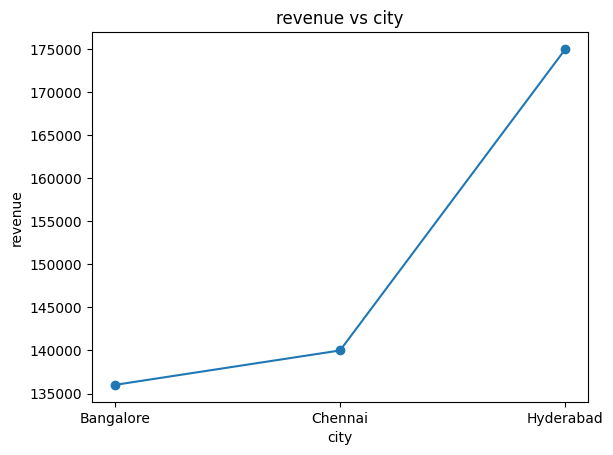

In [ ]:
plt.plot(revenue["city"], revenue["revenue"], marker = "o")
plt.xlabel('city')
plt.ylabel('revenue')
plt.title('revenue vs city')
plt.show()

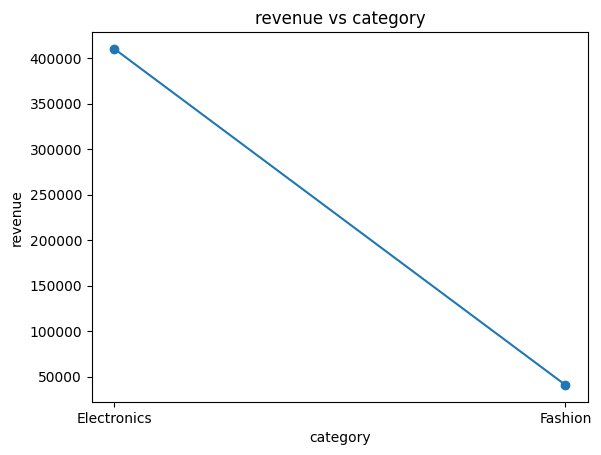

In [ ]:
# find revenue trend (line chart)
revenue = df.groupby("category")["revenue"].sum()
revenue = pd.DataFrame(revenue).reset_index()
plt.plot(revenue["category"], revenue["revenue"], marker = "o")
plt.xlabel('category')
plt.ylabel('revenue')
plt.title('revenue vs category')
plt.show()

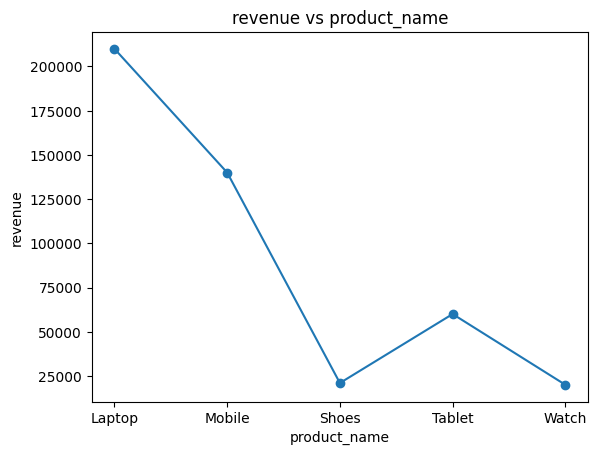

In [ ]:
# find revenue trend (line chart)
revenue = df.groupby("product_name")["revenue"].sum()
revenue = pd.DataFrame(revenue).reset_index()
plt.plot(revenue["product_name"], revenue["revenue"], marker = "o")
plt.xlabel('product_name')
plt.ylabel('revenue')
plt.title('revenue vs product_name')
plt.show()

In [ ]:
df

,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity,product_name,category,price,revenue
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1,Laptop,Electronics,70000,70000
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1,Mobile,Electronics,20000,20000
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1,Laptop,Electronics,70000,70000
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2,Mobile,Electronics,20000,40000
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1,Tablet,Electronics,15000,15000
5,103,Amit,2023-12-15,3,203,2024-01-10,Chennai,1,Tablet,Electronics,15000,15000
6,103,Amit,2023-12-15,12,205,2024-05-09,Chennai,1,Watch,Fashion,5000,5000
7,104,Pooja,2024-01-05,5,204,2024-02-18,Bangalore,3,Shoes,Fashion,3000,9000
8,104,Pooja,2024-01-05,13,202,2024-05-15,Bangalore,1,Mobile,Electronics,20000,20000
9,105,Kiran,2024-01-20,6,201,2024-03-05,Chennai,1,Laptop,Electronics,70000,70000


In [ ]:
# count customers based on order id (count of orders per customer)
df.groupby("customer_id")["order_id"].count()

,order_id
customer_id,
101,3
102,2
103,2
104,2
105,1
106,1
107,1
108,1
109,1


**most customers are ordering less**

this could be because of:
- quality
- price

### CURRENT INSIGHTS:

- revenue is dropping from mid may (last 2 months)
- revenue is dropping in Bangalore
- revenue is dropping in Fashion category

- revenue is dropping for shoes and watch
- repeated customers ordered less




### RECOMMENDED MARKETING STRATEGY:
- Better marketing in Bangalore

- Provde discounts for shoes and watches
- loyalty programs coupons, and discounts